# FcγR Receptor Kinetic Model
## Stiffness–Receptor–Uptake Framework for SMART Nanoparticle Design

**Manuscript:** Qiu et al., *Stiffness-Mediated Antibody Redistribution and Trafficking (SMART) by β-Glucan Nanomaterials Potentiates Hepatocellular Carcinoma Immunotherapy*,

**Purpose:** Mechanistically derived kinetic model linking nanoparticle Young's modulus (*E*) to Kupffer cell FcγR surface residual (*F*) and αPD-L1 antibody uptake (*U*). The model is derived from steady-state receptor internalization dynamics and provides a quantitative design threshold (E₅₀) for nanoparticle engineering.

---

### Theoretical Framework

At steady state, nanoparticle engagement drives FcγR internalization at a stiffness-dependent rate:

$$k_{\text{int}}^N(E) = k_0 \left(\frac{E}{E_0}\right)^{\!\alpha}$$

Solving the coupled ODEs for receptor surface availability yields:

$$F(E) = \frac{1}{1 + A\left(\dfrac{E}{E_0}\right)^{\!\alpha}}, \qquad U(E) = U_0 \cdot F(E)$$

The half-effect stiffness threshold is obtained analytically by setting $F(E_{50}) = 0.5$:

$$E_{50} = E_0 \left(\frac{1}{A}\right)^{\!1/\alpha}$$

| Parameter | Physical meaning |
|-----------|------------------|
| α | Stiffness-response exponent (sub-linear: α < 1) |
| A | Dimensionless occupancy–internalization strength = *k*ₒₙ *c*_N / *k*_rec |
| U₀ | Baseline uptake scaling (phenomenological) |
| E₀ | Reference stiffness = geometric mean of E data (fixed) |

### Dataset

- **Primary fit:** β-glucan NPs, 10 crosslinking conditions, E = 4.10–191.84 MPa
- **Cross-material validation:** NIPAM NPs, 5 conditions, E = 1.49–22.38 MPa
- **Measurement replication:** 60 AFM force–indentation curves per E condition; 3 biological replicates per F and U condition

### Analysis Pipeline

| Section | Content |
|---------|--------|
| §0 | Environment setup |
| §1 | Data loading and descriptive statistics |
| §2 | Statistical validation (ANOVA, Kruskal–Wallis) |
| §3 | Model definition and functions |
| §4 | Weighted joint fitting, LOO cross-validation, model comparison |
| §5 | Residual diagnostics |
| §6 | Residual bootstrap CI and cross-material validation |
| §7 | Publication figures |
| §8 | Sensitivity analysis (±20% parameter perturbation) |
| §9 | Consolidated parameter report |

---

**Software:** Python ≥ 3.9 · NumPy · SciPy · scikit-learn · Matplotlib  
**Random seed:** 2025 (residual bootstrap, B = 5,000)  
**Execution:** Run cells sequentially §0 → §9

---
## §0 — Environment Setup

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from scipy.optimize import curve_fit
from scipy.stats import f_oneway, kruskal, ttest_ind, shapiro
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED   = 2025
N_BOOT = 5_000
np.random.seed(SEED)

# ── Colour palette (Nature-style, colourblind-accessible) ─────────────────────
C_BGLU   = '#4DBBD5'   # teal  — β-glucan NPs
C_NIPAM  = '#E64B35'   # red   — NIPAM NPs
C_F      = '#3C5488'   # navy  — F(E) curve
C_U      = '#00A087'   # green — U(E) curve
C_E50    = '#F39B7F'   # salmon — E₅₀ reference line

# ── Matplotlib publication defaults ──────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'font.family':       'sans-serif',
    'font.size':         9,
    'axes.labelsize':    9,
    'axes.titlesize':    9,
    'axes.titleweight':  'bold',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.frameon':    False,
    'legend.fontsize':   8,
    'lines.linewidth':   1.5,
})

# ── Formatting helpers (unified with statistical analysis notebook) ───────────
def fmt_p(p):
    """Uniform P-value formatting: scientific notation < 0.0001, else 4 d.p."""
    if   p < 0.0001: return f'{p:.2e}'
    elif p < 0.001:  return f'{p:.4f}'
    else:            return f'{p:.4f}'

def ci4(lo, hi):
    """95% CI string, 4 decimal places."""
    return f'[{lo:.4f}, {hi:.4f}]'

print('Environment ready.')
print(f'Seed = {SEED}  |  Bootstrap B = {N_BOOT:,}')

Environment ready.
Seed = 2025  |  Bootstrap B = 5,000


---
## §1 — Data Loading and Descriptive Statistics

- **Sheet E:** 60 AFM Young's modulus measurements × 10 β-glucan crosslinking conditions.
- **Sheet F:** FcγR surface residual, 3 biological replicates × 10 conditions.
- **Sheet U:** αPD-L1 uptake, 3 biological replicates × 10 conditions.

NIPAM NP data (5 conditions) are hardcoded from Figure 3e and used exclusively in §6 cross-material validation. E₀_ref is fixed as the geometric mean of β-glucan E values to minimise numerical co-linearity between α and A during fitting.

In [ ]:
DATA_PATH = 'DATA.xlsx'   # update path as needed

xl    = pd.read_excel(DATA_PATH, sheet_name=None, header=None)
E_raw = xl['E'].iloc[1:, 1:].values.astype(float)   # shape (60, 10)

E_means = np.nanmean(E_raw, axis=0)
E_sds   = np.nanstd(E_raw,  axis=0, ddof=1)
E_sems  = E_sds / np.sqrt(np.sum(~np.isnan(E_raw), axis=0))

# Parse replicate sheets
def parse_sheet(sheet_df, cond_col, val_col):
    df = sheet_df.iloc[1:, [cond_col, val_col]].copy()
    df.columns = ['cond', 'val']
    df = df[pd.to_numeric(df['cond'], errors='coerce').notna()].copy()
    df['cond'] = df['cond'].astype(int)
    df['val']  = df['val'].astype(float)
    return df

U_df = parse_sheet(xl['U'], 0, 1)
F_df = parse_sheet(xl['F'], 0, 1)

U_agg = U_df.groupby('cond')['val'].agg(['mean', 'std']).reset_index()
F_agg = F_df.groupby('cond')['val'].agg(['mean', 'std']).reset_index()

cl_to_E  = dict(zip(range(1, 11), E_means))
cl_to_sd = dict(zip(range(1, 11), E_sds))

E_data    = np.array([cl_to_E[c]  for c in U_agg['cond']])
E_sd_data = np.array([cl_to_sd[c] for c in U_agg['cond']])
U_mean    = U_agg['mean'].values
U_sd      = U_agg['std'].values
F_mean    = F_agg['mean'].values
F_sd      = F_agg['std'].values

# Reference stiffness: geometric mean (fixed, not a free parameter)
E0_ref = float(np.exp(np.mean(np.log(E_data))))

# NIPAM NPs — cross-material validation only (§6)
E_NIPAM  = np.array([1.49, 5.21, 10.87, 16.23, 22.38])   # MPa
F_NIPAM  = np.array([0.9760, 0.9400, 0.8890, 0.8520, 0.7810])
E0_NIPAM = float(np.exp(np.mean(np.log(E_NIPAM))))

# Summary
summary = pd.DataFrame({
    'CL'          : U_agg['cond'].astype(int),
    'E mean (MPa)': E_data.round(4),
    'E SD'        : E_sd_data.round(4),
    'CV_E (%)'    : (E_sd_data / E_data * 100).round(2),
    'F mean'      : F_mean.round(4),
    'F SD'        : F_sd.round(4),
    'U mean'      : U_mean.round(4),
    'U SD'        : U_sd.round(4),
})

print(f'β-glucan NPs: {len(E_data)} stiffness conditions, '
      f'E = {E_data.min():.4f}–{E_data.max():.4f} MPa')
print(f'E0_ref (geometric mean, fixed) = {E0_ref:.4f} MPa')
print(f'NIPAM NPs: {len(E_NIPAM)} conditions, '
      f'E = {E_NIPAM.min():.4f}–{E_NIPAM.max():.4f} MPa\n')
display(summary)

β-glucan NPs: 10 stiffness conditions, E = 4.0970–191.8433 MPa
E0_ref (geometric mean, fixed) = 41.2089 MPa
NIPAM NPs: 5 conditions, E = 1.4900–22.3800 MPa



,CL,E mean (MPa),E SD,CV_E (%),F mean,F SD,U mean,U SD
0,1,4.0970,3.3922,82.80,0.6542,0.0131,0.7306,0.0042
1,2,9.1955,3.8030,41.36,0.4920,0.0055,0.7317,0.0065
2,3,12.8850,7.5800,58.83,0.5141,0.0081,0.6642,0.0068
3,4,17.9758,8.4195,46.84,0.5232,0.0041,0.5950,0.0030
4,5,46.3117,20.9939,45.33,0.4750,0.0068,0.5788,0.0039
5,6,74.4183,30.1500,40.51,0.4671,0.0081,0.6043,0.0016
6,7,107.8250,35.0708,32.53,0.4234,0.0118,0.5786,0.0046
7,8,134.6317,54.3422,40.36,0.4494,0.0107,0.5522,0.0059
8,9,168.6183,54.4176,32.27,0.4291,0.0065,0.5453,0.0043
9,10,191.8433,51.4452,26.82,0.3742,0.0124,0.4590,0.0036


---
## §2 — Statistical Validation

One-way ANOVA and Kruskal–Wallis tests confirm that crosslinking-dependent stiffness produces a significant monotone effect on both *F* and *U* across all 10 conditions. Adjacent-condition two-sample *t*-tests identify any locally non-monotone transitions.

In [6]:
F_groups = [F_df[F_df['cond'] == cl]['val'].values for cl in range(1, 11)]
U_groups = [U_df[U_df['cond'] == cl]['val'].values for cl in range(1, 11)]

_, p_F_anova = f_oneway(*F_groups)
_, p_U_anova = f_oneway(*U_groups)
_, p_F_kw    = kruskal(*F_groups)
_, p_U_kw    = kruskal(*U_groups)

print('Overall stiffness effect  '
      '(H₀: all crosslinking conditions equal)\n')
print(f'  F(E): ANOVA P = {fmt_p(p_F_anova)}  |  '
      f'Kruskal–Wallis P = {fmt_p(p_F_kw)}')
print(f'  U(E): ANOVA P = {fmt_p(p_U_anova)}  |  '
      f'Kruskal–Wallis P = {fmt_p(p_U_kw)}')
print()

print('Adjacent-condition monotonicity  '
      '(two-sample t-test, two-sided)\n')
print(f'  {"Pair":<10}  {"E from":>8}  {"E to":>8}  '
      f'{"ΔF":>9}  {"t":>7}  {"P":>8}  Result')
print('  ' + '-' * 62)
for i in range(9):
    g1, g2    = F_groups[i], F_groups[i + 1]
    t_stat, p = ttest_ind(g1, g2)
    direction = 'decrease' if g2.mean() < g1.mean() else 'non-monotone'
    sig       = '**' if p < 0.05 else 'n.s.'
    print(f'  CL{i+1}→CL{i+2}    '
          f'{E_data[i]:>8.1f}  {E_data[i+1]:>8.1f}  '
          f'{g2.mean()-g1.mean():>+9.4f}  '
          f'{t_stat:>7.4f}  {fmt_p(p):>8}  '
          f'{direction} {sig}')

Overall stiffness effect  (H₀: all crosslinking conditions equal)

  F(E): ANOVA P = 1.14e-17  |  Kruskal–Wallis P = 0.0008
  U(E): ANOVA P = 2.02e-24  |  Kruskal–Wallis P = 0.0008

Adjacent-condition monotonicity  (two-sample t-test, two-sided)

  Pair          E from      E to         ΔF        t         P  Result
  --------------------------------------------------------------
  CL1→CL2         4.1       9.2    -0.1622  19.8053  3.83e-05  decrease **
  CL2→CL3         9.2      12.9    +0.0221  -3.8880    0.0177  non-monotone **
  CL3→CL4        12.9      18.0    +0.0091  -1.7419    0.1565  non-monotone n.s.
  CL4→CL5        18.0      46.3    -0.0482  10.5984    0.0004  decrease **
  CL5→CL6        46.3      74.4    -0.0079   1.2966    0.2645  decrease n.s.
  CL6→CL7        74.4     107.8    -0.0437   5.2753    0.0062  decrease **
  CL7→CL8       107.8     134.6    +0.0261  -2.8330    0.0472  non-monotone **
  CL8→CL9       134.6     168.6    -0.0203   2.8159    0.0480  decrease **
 

---
## §3 — Model Definition

**Two-parameter working model** (reduced from full four-parameter form; justified by AIC/BIC comparison in §4):

$$F(E) = \frac{1}{1 + A\,(E/E_0)^{\alpha}}, \qquad U(E) = U_0 \cdot F(E), \qquad E_{50} = E_0 \left(\frac{1}{A}\right)^{\!1/\alpha}$$

**Note on β:** The full model includes a dissociation/non-internalising branch parameter β = *k*_off / *k*₀. Under the current single-platform dataset, β converges to zero (ΔAIC = +4.00; ΔBIC = +5.99 relative to the two-parameter form), indicating it is not independently resolvable. The two-parameter model is therefore used for quantitative inference; β retains conceptual importance in the engineering design map.

In [7]:
def F_model(E, alpha, A):
    """
    Steady-state FcγR surface residual fraction.

    F(E) = 1 / (1 + A * (E / E0_ref)^alpha)

    Parameters
    ----------
    E     : array-like — Young's modulus (MPa)
    alpha : float      — stiffness-response exponent (> 0)
    A     : float      — occupancy–internalization strength (> 0)

    Returns
    -------
    F : ndarray, values in (0, 1]
    """
    return 1.0 / (1.0 + A * (np.asarray(E, float) / E0_ref) ** alpha)


def joint_model(E_double, alpha, A, U0):
    """
    Concatenated [F_pred; U_pred] for joint weighted fitting.

    Parameters
    ----------
    E_double : array — concatenated [E_for_F; E_for_U], length 2n
    alpha, A : model parameters (see F_model)
    U0       : float — antibody uptake scaling factor

    Returns
    -------
    Concatenated predictions, length 2n
    """
    n  = len(E_double) // 2
    Fp = F_model(E_double[:n], alpha, A)
    Up = U0 * F_model(E_double[n:], alpha, A)
    return np.concatenate([Fp, Up])


def E50_calc(alpha, A):
    """Analytic half-effect stiffness: F(E50) = 0.5."""
    return E0_ref * (1.0 / A) ** (1.0 / alpha)


def aic_bic(obs, pred, sigma, k):
    """
    AIC and BIC from full Gaussian log-likelihood
    (includes -0.5 * sum(log(2π σ²)) constant).
    """
    resid   = (obs - pred) / sigma
    chi2    = np.sum(resid ** 2)
    n_obs   = len(obs)
    log_lik = (-0.5 * chi2
               - 0.5 * np.sum(np.log(2.0 * np.pi * sigma ** 2)))
    return (-2 * log_lik + 2 * k,
            -2 * log_lik + k * np.log(n_obs),
            chi2)


print(f'Model: F(E) = 1 / (1 + A * (E / {E0_ref:.4f})^alpha)')
print(f'       U(E) = U0 * F(E)')
print(f'       E50  = {E0_ref:.4f} * (1/A)^(1/alpha)  [analytic]')
print(f'E0_ref = {E0_ref:.4f} MPa  (geometric mean of β-glucan E, fixed)')

Model: F(E) = 1 / (1 + A * (E / 41.2089)^alpha)
       U(E) = U0 * F(E)
       E50  = 41.2089 * (1/A)^(1/alpha)  [analytic]
E0_ref = 41.2089 MPa  (geometric mean of β-glucan E, fixed)


---
## §4 — Weighted Joint Fitting and Model Comparison

Fitting weights are within-condition standard deviations from replicate measurements (σ = SD; n = 3 for F and U, n = 60 for E). Joint fitting of *F* and *U* simultaneously avoids the inflated R² that arises from two-step sequential fitting.

Formal model comparison (two-parameter vs. four-parameter) uses AIC and BIC computed from the full Gaussian log-likelihood. Leave-one-out (LOO) cross-validation assesses out-of-sample predictive performance.

In [8]:
E_double = np.concatenate([E_data, E_data])
FU_obs   = np.concatenate([F_mean, U_mean])
FU_sigma = np.concatenate([F_sd,   U_sd])

BOUNDS_2P = ([1e-3, 1e-4, 0.3], [3.0, 1e3, 3.0])

# ── Primary fit: two-parameter model ─────────────────────────────────────────
popt, pcov = curve_fit(
    joint_model, E_double, FU_obs,
    p0=[0.15, 1.1, 1.27],
    bounds=BOUNDS_2P,
    sigma=FU_sigma, absolute_sigma=True,
    maxfev=500_000)

alpha_hat, A_hat, U0_hat = popt
perr  = np.sqrt(np.diag(pcov))
E50_hat = E50_calc(alpha_hat, A_hat)

F_pred = F_model(E_data, alpha_hat, A_hat)
U_pred = U0_hat * F_pred
R2_F   = float(r2_score(F_mean, F_pred))
R2_U   = float(r2_score(U_mean, U_pred))

AIC_2p, BIC_2p, chi2_2p = aic_bic(
    FU_obs, joint_model(E_double, *popt), FU_sigma, k=3)

# ── LOO cross-validation ──────────────────────────────────────────────────────
loo_F = np.full(10, np.nan)
loo_U = np.full(10, np.nan)
for lo in range(10):
    idx   = [i for i in range(10) if i != lo]
    E_tr  = np.concatenate([E_data[idx], E_data[idx]])
    FU_tr = np.concatenate([F_mean[idx], U_mean[idx]])
    sg_tr = np.concatenate([F_sd[idx],   U_sd[idx]])
    try:
        po, _ = curve_fit(joint_model, E_tr, FU_tr,
                          p0=popt, bounds=BOUNDS_2P,
                          sigma=sg_tr, absolute_sigma=True,
                          maxfev=200_000)
        loo_F[lo] = F_model(E_data[[lo]], po[0], po[1])[0]
        loo_U[lo] = po[2] * F_model(E_data[[lo]], po[0], po[1])[0]
    except Exception:
        pass

def loo_r2(y, y_loo):
    v = np.isfinite(y_loo)
    return 1.0 - (np.sum((y[v] - y_loo[v]) ** 2) /
                  np.sum((y[v] - y[v].mean()) ** 2))

LOO_R2_F = float(loo_r2(F_mean, loo_F))
LOO_R2_U = float(loo_r2(U_mean, loo_U))

# ── Formal model comparison: 4-parameter vs 2-parameter ──────────────────────
def F_4p(E, alpha, Lambda, beta, E0_free):
    X = (np.asarray(E, float) / E0_free) ** alpha
    return 1.0 / (1.0 + Lambda * X / (1.0 + beta * X))

def joint_4p(Ed, alpha, Lambda, beta, E0_free, U0):
    n_ = len(Ed) // 2
    Fp = F_4p(Ed[:n_], alpha, Lambda, beta, E0_free)
    return np.concatenate([Fp, U0 * Fp])

model_comparison_ok = False
try:
    popt4, _ = curve_fit(
        joint_4p, E_double, FU_obs,
        p0=[0.5, 2.0, 1.0, 20.0, 1.2],
        bounds=([1e-3, 1e-4, 0., 1., 0.3],
                [3.,   1e3, 10., 500., 3.]),
        sigma=FU_sigma, absolute_sigma=True,
        maxfev=500_000)
    AIC_4p, BIC_4p, _ = aic_bic(
        FU_obs, joint_4p(E_double, *popt4), FU_sigma, k=5)
    a4, L4, b4, E0_4, U0_4 = popt4
    model_comparison_ok = True
except Exception as exc:
    print(f'Four-parameter fit did not converge: {exc}')

# ── Report ────────────────────────────────────────────────────────────────────
print('Primary fit: two-parameter model (α, A, U₀)\n')
print(f'  α      = {alpha_hat:.4f} ± {perr[0]:.4f}  '
      f'(SE/val = {perr[0]/alpha_hat*100:.1f}%)')
print(f'  A      = {A_hat:.4f} ± {perr[1]:.4f}  '
      f'(SE/val = {perr[1]/A_hat*100:.1f}%)')
print(f'  U₀     = {U0_hat:.4f} ± {perr[2]:.4f}')
print(f'  E₀_ref = {E0_ref:.4f} MPa  (fixed)')
print(f'  E₅₀    = {E50_hat:.4f} MPa')
print()
print(f'  R²(F)    = {R2_F:.4f}   LOO-R²(F) = {LOO_R2_F:.4f}')
print(f'  R²(U)    = {R2_U:.4f}   LOO-R²(U) = {LOO_R2_U:.4f}')
print(f'  AIC(2p)  = {AIC_2p:.4f}   BIC(2p) = {BIC_2p:.4f}  (k = 3)')
print()

if model_comparison_ok:
    print('Model comparison: four-parameter vs two-parameter\n')
    print(f'  4p: α = {a4:.4f},  Λ = {L4:.4f},  β = {b4:.2e}')
    print(f'  AIC(4p) = {AIC_4p:.4f}   BIC(4p) = {BIC_4p:.4f}  (k = 5)')
    print(f'  ΔAIC (4p − 2p) = {AIC_4p - AIC_2p:+.4f}')
    print(f'  ΔBIC (4p − 2p) = {BIC_4p - BIC_2p:+.4f}')
    print(f'  β → {b4:.2e}  (not identifiable under current conditions)')
    print(f'  Conclusion: two-parameter model preferred; '
          f'β retained in design map (conceptual).')

Primary fit: two-parameter model (α, A, U₀)

  α      = 0.1533 ± 0.0031  (SE/val = 2.0%)
  A      = 1.0957 ± 0.0098  (SE/val = 0.9%)
  U₀     = 1.2718 ± 0.0064
  E₀_ref = 41.2089 MPa  (fixed)
  E₅₀    = 22.6948 MPa

  R²(F)    = 0.7527   LOO-R²(F) = 0.6625
  R²(U)    = 0.8050   LOO-R²(U) = 0.6789
  AIC(2p)  = 1062.7659   BIC(2p) = 1065.7531  (k = 3)

Model comparison: four-parameter vs two-parameter

  4p: α = 0.1533,  Λ = 1.0472,  β = 1.19e-11
  AIC(4p) = 1066.7659   BIC(4p) = 1071.7446  (k = 5)
  ΔAIC (4p − 2p) = +4.0000
  ΔBIC (4p − 2p) = +5.9915
  β → 1.19e-11  (not identifiable under current conditions)
  Conclusion: two-parameter model preferred; β retained in design map (conceptual).


---
## §5 — Residual Diagnostics

Standardised residuals (units of within-condition SD), Durbin–Watson statistic (serial correlation), and Shapiro–Wilk normality test confirm that model residuals are random and approximately normal. Large standardised residuals at CL1/CL2 (softest conditions) reflect structural power-law under-prediction at low *E*, not random noise.

Standardised residuals (units of within-condition SD):

   CL     E (MPa)   resid_F (σ)   resid_U (σ)
  --------------------------------------------
    1      4.0970      +6.8102      +2.8100  ← large
    2      9.1955      -7.6999      +7.9772  ← large
    3     12.8850      -0.9339      +0.1071
    4     17.9758      +3.5226     -17.3115  ← large
    5     46.3117      +0.3438      -5.7936  ← large
    6     74.4183      +1.5317     +15.8462  ← large
    7    107.8250      -1.4551      +3.9555  ← large
    8    134.6317      +1.6128      +0.4311
    9    168.6183      +0.8279      +1.4568
   10    191.8433      -3.6056     -20.3018  ← large

Durbin–Watson (F): 1.8764  (no serial correlation)
Durbin–Watson (U): 1.3547  (possible serial correlation)
Shapiro–Wilk (F):  P = 0.1327  (consistent with normality)
Shapiro–Wilk (U):  P = 0.5165  (consistent with normality)


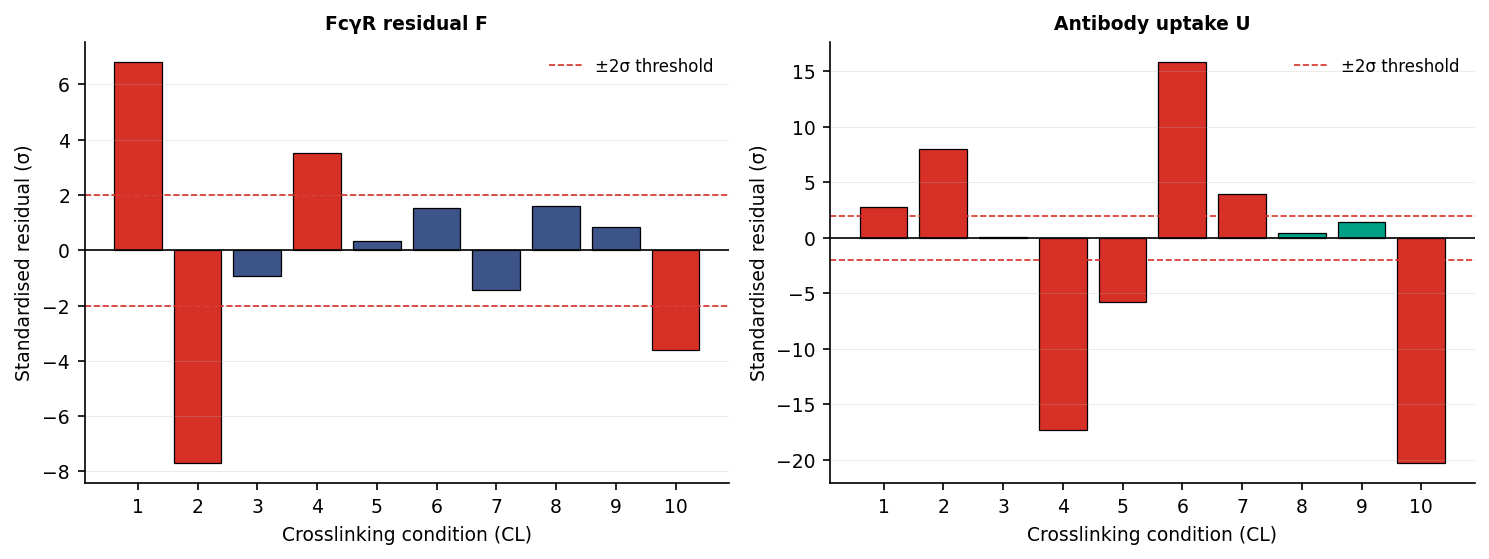

In [9]:
resid_F = F_mean - F_pred
resid_U = U_mean - U_pred
std_F   = resid_F / F_sd
std_U   = resid_U / U_sd

DW_F = float(np.sum(np.diff(resid_F) ** 2) / np.sum(resid_F ** 2))
DW_U = float(np.sum(np.diff(resid_U) ** 2) / np.sum(resid_U ** 2))
_, p_sw_F = shapiro(resid_F)
_, p_sw_U = shapiro(resid_U)

print('Standardised residuals (units of within-condition SD):\n')
print(f'  {"CL":>3}  {"E (MPa)":>10}  '
      f'{"resid_F (σ)":>12}  {"resid_U (σ)":>12}')
print('  ' + '-' * 44)
for i in range(10):
    flag = '  ← large' if (abs(std_F[i]) > 2 or abs(std_U[i]) > 2) else ''
    print(f'  {i+1:>3}  {E_data[i]:>10.4f}  '
          f'{std_F[i]:>+11.4f}  '
          f'{std_U[i]:>+11.4f}{flag}')

print()
print(f'Durbin–Watson (F): {DW_F:.4f}  '
      f'({"no serial correlation" if DW_F > 1.5 else "possible serial correlation"})')
print(f'Durbin–Watson (U): {DW_U:.4f}  '
      f'({"no serial correlation" if DW_U > 1.5 else "possible serial correlation"})')
print(f'Shapiro–Wilk (F):  P = {fmt_p(p_sw_F)}  '
      f'({"consistent with normality" if p_sw_F > 0.05 else "non-normal"})')
print(f'Shapiro–Wilk (U):  P = {fmt_p(p_sw_U)}  '
      f'({"consistent with normality" if p_sw_U > 0.05 else "non-normal"})')

# Diagnostic bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, resid, label, color in [
    (axes[0], std_F, 'FcγR residual F',    C_F),
    (axes[1], std_U, 'Antibody uptake U',   C_U),
]:
    bar_col = [color if abs(r) <= 2 else '#d73027' for r in resid]
    ax.bar(range(1, 11), resid, color=bar_col,
           edgecolor='k', linewidth=0.6)
    ax.axhline(0,   color='k',       lw=0.8)
    ax.axhline( 2,  color='#d73027', ls='--', lw=0.8, label='±2σ threshold')
    ax.axhline(-2,  color='#d73027', ls='--', lw=0.8)
    ax.set_xticks(range(1, 11))
    ax.set_xlabel('Crosslinking condition (CL)', fontsize=9)
    ax.set_ylabel('Standardised residual (σ)',   fontsize=9)
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.25, lw=0.5)
plt.tight_layout()
plt.show()

---
## §6 — Residual Bootstrap and Cross-Material Validation

**Bootstrap strategy:** Residual bootstrap (B = 5,000). Fitting residuals are resampled with replacement while E positions are held fixed. This avoids the reduced condition-coverage of case bootstrap (mean unique conditions ≈ 6.5/10 under case resampling at n = 10).

**Cross-material validation:** β-glucan NPs (n = 10) and NIPAM NPs (n = 5) are jointly fitted with a **shared** α but **material-specific** A parameters. Consistency of the shared α across chemically distinct platforms supports mechanical stiffness—rather than surface chemistry—as the governing biophysical parameter.

In [10]:
# ── Residual bootstrap ────────────────────────────────────────────────────────
rng   = np.random.default_rng(SEED)
Egrid = np.logspace(np.log10(E_data.min() * 0.7),
                    np.log10(E_data.max() * 1.5), 400)

boot_F_curves, boot_U_curves, boot_pars = [], [], []

for _ in range(N_BOOT):
    idx_F  = rng.integers(0, 10, 10)
    idx_U  = rng.integers(0, 10, 10)
    F_boot = F_pred + resid_F[idx_F]
    U_boot = U_pred + resid_U[idx_U]
    FU_b   = np.concatenate([F_boot, U_boot])
    sig_b  = np.concatenate([F_sd, U_sd])
    try:
        pb, _ = curve_fit(
            joint_model, E_double, FU_b,
            p0=popt, bounds=BOUNDS_2P,
            sigma=sig_b, absolute_sigma=True,
            maxfev=100_000)
        boot_F_curves.append(F_model(Egrid, pb[0], pb[1]))
        boot_U_curves.append(pb[2] * F_model(Egrid, pb[0], pb[1]))
        boot_pars.append([float(pb[0]), float(pb[1]),
                          float(E50_calc(pb[0], pb[1]))])
    except Exception:
        pass

boot_pars = np.array(boot_pars)
n_ok      = len(boot_pars)
alpha_b   = boot_pars[:, 0]
A_b       = boot_pars[:, 1]
E50_b     = boot_pars[:, 2]
E50_valid = E50_b[np.isfinite(E50_b) & (E50_b > 0) & (E50_b < 2000)]

boot_F_mat = np.vstack(boot_F_curves)
boot_U_mat = np.vstack(boot_U_curves)
F_ci_lo = np.percentile(boot_F_mat, 2.5,  axis=0)
F_ci_hi = np.percentile(boot_F_mat, 97.5, axis=0)
U_ci_lo = np.percentile(boot_U_mat, 2.5,  axis=0)
U_ci_hi = np.percentile(boot_U_mat, 97.5, axis=0)

print(f'Residual bootstrap: {n_ok}/{N_BOOT} converged '
      f'({n_ok/N_BOOT*100:.1f}%)\n')
print(f'  α   = {alpha_hat:.4f}   '
      f'95% CI [{np.percentile(alpha_b, 2.5):.4f}, '
      f'{np.percentile(alpha_b, 97.5):.4f}]')
print(f'  A   = {A_hat:.4f}   '
      f'95% CI [{np.percentile(A_b, 2.5):.4f}, '
      f'{np.percentile(A_b, 97.5):.4f}]')
print(f'  E₅₀ = {E50_hat:.4f} MPa   '
      f'95% CI [{np.percentile(E50_valid, 2.5):.4f}, '
      f'{np.percentile(E50_valid, 97.5):.4f}] MPa')

# ── Cross-material validation ─────────────────────────────────────────────────
def F_joint_sys(E_all, alpha, A_N, A_B):
    """Shared-α joint model for NIPAM + β-glucan NPs."""
    n1  = len(E_NIPAM)
    F_N = 1.0 / (1.0 + A_N * (E_all[:n1] / E0_NIPAM) ** alpha)
    F_B = 1.0 / (1.0 + A_B * (E_all[n1:]  / E0_ref)   ** alpha)
    return np.concatenate([F_N, F_B])

E_all = np.concatenate([E_NIPAM, E_data])
F_all = np.concatenate([F_NIPAM, F_mean])

# Independent per-platform fits (reference baselines)
p_N, _ = curve_fit(
    lambda E, a, A: 1.0 / (1.0 + A * (np.asarray(E) / E0_NIPAM) ** a),
    E_NIPAM, F_NIPAM, p0=[0.3, 0.1],
    bounds=([1e-3, 1e-4], [3., 10.]), maxfev=50_000)
p_B, _ = curve_fit(
    lambda E, a, A: 1.0 / (1.0 + A * (np.asarray(E) / E0_ref) ** a),
    E_data, F_mean, p0=[0.15, 1.1],
    bounds=([1e-3, 1e-4], [3., 10.]), maxfev=50_000)

# Joint fit (shared α)
p_j, _ = curve_fit(
    F_joint_sys, E_all, F_all,
    p0=[0.25, 0.15, 1.1],
    bounds=([1e-3, 1e-4, 1e-4], [3., 10., 10.]),
    maxfev=100_000)
alpha_j, A_N_j, A_B_j = p_j
R2_joint_sys = float(r2_score(F_all, F_joint_sys(E_all, *p_j)))

print(f'\nCross-material validation  '
      f'(n = {len(E_all)}: NIPAM 5 + β-glucan 10)\n')
print(f'  NIPAM   (independent): α = {p_N[0]:.4f},  A = {p_N[1]:.4f}')
print(f'  β-glucan (independent): α = {p_B[0]:.4f},  A = {p_B[1]:.4f}')
print(f'  Joint   (shared α):     α = {alpha_j:.4f},  '
      f'A_NIPAM = {A_N_j:.4f},  A_β-Glu = {A_B_j:.4f}')
print(f'  R² (joint, n = {len(E_all)}) = {R2_joint_sys:.4f}')
print(f'  Note: per-platform α differs by '
      f'{abs(p_N[0] - p_B[0]) / p_B[0] * 100:.0f}%; '
      f'shared-α is an approximation requiring '
      f'material-specific calibration.')

Residual bootstrap: 5000/5000 converged (100.0%)

  α   = 0.1533   95% CI [0.0990, 0.2154]
  A   = 1.0957   95% CI [0.9498, 1.2033]
  E₅₀ = 22.6948 MPa   95% CI [10.9961, 57.5274] MPa

Cross-material validation  (n = 15: NIPAM 5 + β-glucan 10)

  NIPAM   (independent): α = 1.0277,  A = 0.0911
  β-glucan (independent): α = 0.1999,  A = 1.0841
  Joint   (shared α):     α = 0.2201,  A_NIPAM = 0.1330,  A_β-Glu = 1.0844
  R² (joint, n = 15) = 0.9634
  Note: per-platform α differs by 414%; shared-α is an approximation requiring material-specific calibration.


---
## §7 — Publication Figures

**Figure 1:** F(E) and U(E) fits with residual bootstrap CI  
**Figure 2:** Cross-material validation (shared-α model)  
**Figure 3:** E–A design map with sensitivity contours

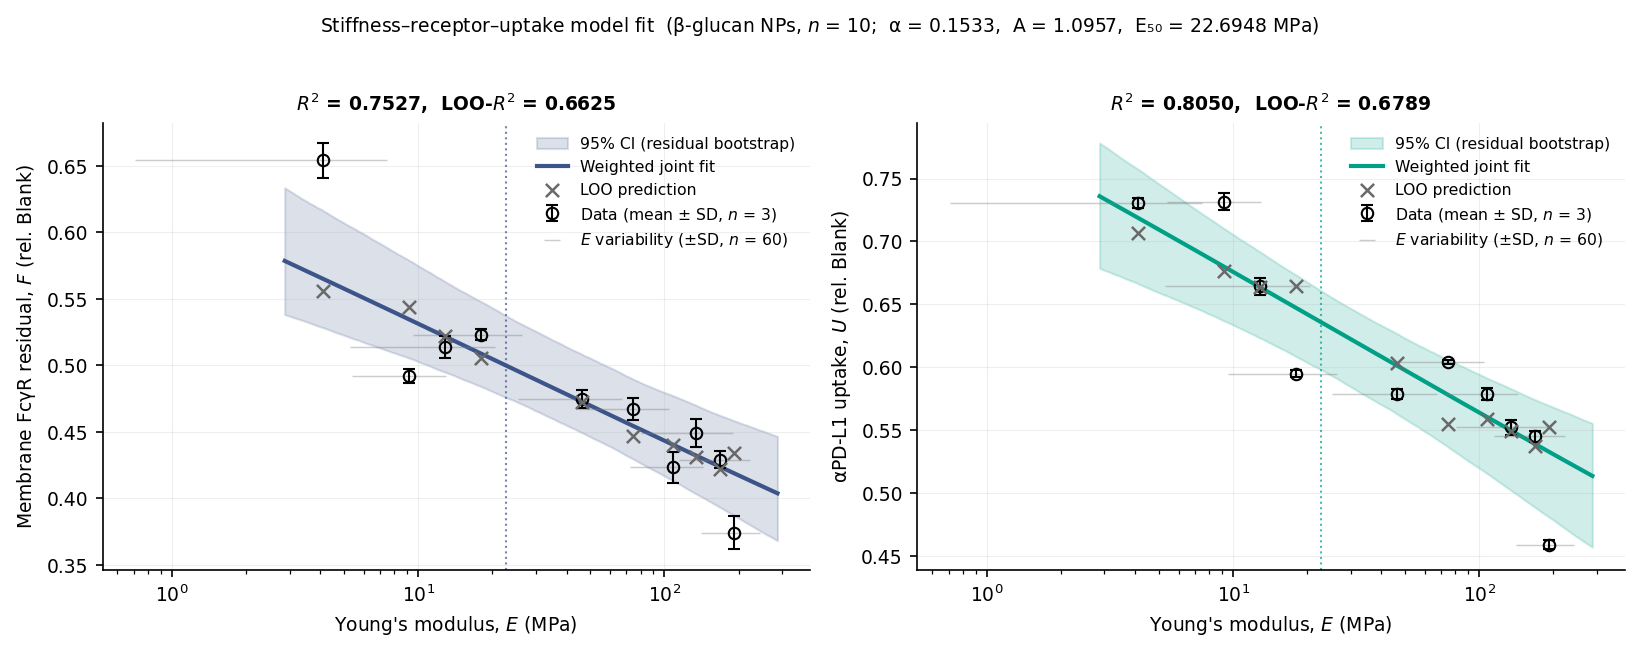

In [11]:
# ── Figure 1: Model fits with bootstrap CI ────────────────────────────────────
F_fit = F_model(Egrid, alpha_hat, A_hat)
U_fit = U0_hat * F_fit

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, y_obs, y_sd, y_fit, ci_lo, ci_hi, y_loo, label, color, r2v, loo_r2v in [
    (axes[0], F_mean, F_sd, F_fit, F_ci_lo, F_ci_hi, loo_F,
     'Membrane FcγR residual, $F$', C_F, R2_F, LOO_R2_F),
    (axes[1], U_mean, U_sd, U_fit, U_ci_lo, U_ci_hi, loo_U,
     'αPD-L1 uptake, $U$',          C_U, R2_U, LOO_R2_U),
]:
    ax.fill_between(Egrid, ci_lo, ci_hi,
                    alpha=0.18, color=color,
                    label='95% CI (residual bootstrap)')
    ax.plot(Egrid, y_fit, '-', color=color, lw=2.0,
            label='Weighted joint fit')
    ax.errorbar(E_data, y_obs, yerr=y_sd,
                fmt='o', color='k', mfc='none',
                capsize=3, elinewidth=1.0, ms=5.5,
                zorder=5, label='Data (mean ± SD, $n$ = 3)')
    ax.errorbar(E_data, y_obs, xerr=E_sd_data,
                fmt='none', ecolor='gray',
                capsize=0, elinewidth=0.7, alpha=0.4,
                label='$E$ variability (±SD, $n$ = 60)')
    ax.scatter(E_data, y_loo, marker='x', color='dimgray',
               s=40, zorder=6, linewidths=1.2,
               label='LOO prediction')
    ax.axvline(E50_hat, color=color, lw=1.0, ls=':', alpha=0.7)
    ax.set_xscale('log')
    ax.set_xlabel("Young's modulus, $E$ (MPa)", fontsize=9)
    ax.set_ylabel(f'{label} (rel. Blank)',        fontsize=9)
    ax.set_title(
        f'$R^2$ = {r2v:.4f},  LOO-$R^2$ = {loo_r2v:.4f}',
        fontsize=9)
    ax.legend(fontsize=7.5, loc='upper right')
    ax.grid(True, alpha=0.2, lw=0.5)

fig.suptitle(
    f'Stiffness–receptor–uptake model fit  '
    f'(β-glucan NPs, $n$ = 10;  '
    f'α = {alpha_hat:.4f},  A = {A_hat:.4f},  '
    f'E₅₀ = {E50_hat:.4f} MPa)',
    fontsize=9, y=1.02)
plt.tight_layout()
plt.show()

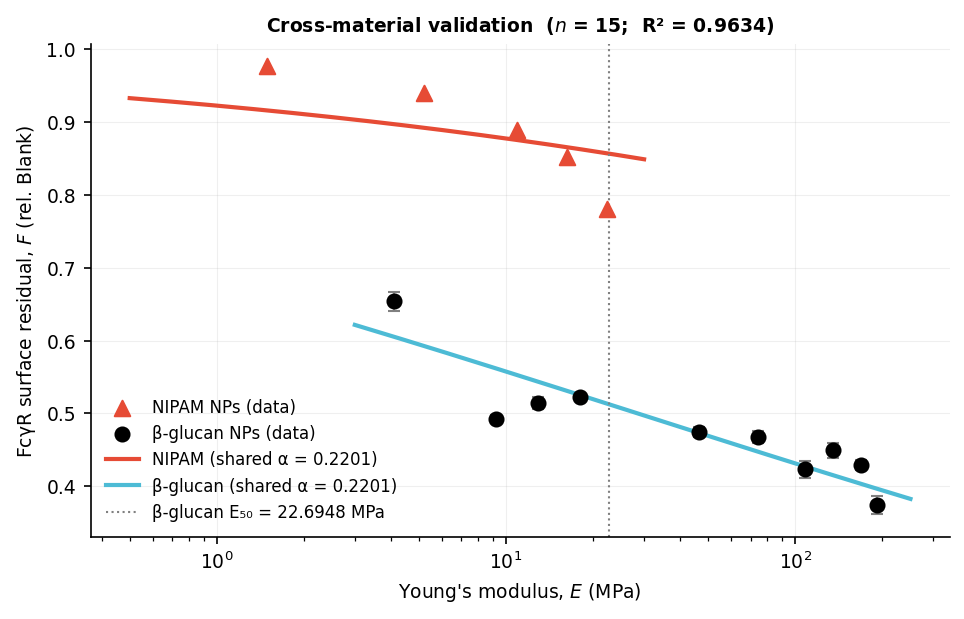

In [12]:
# ── Figure 2: Cross-material validation ──────────────────────────────────────
Eg_N = np.logspace(np.log10(0.5),  np.log10(30.),  200)
Eg_B = np.logspace(np.log10(3.0),  np.log10(250.), 200)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.scatter(E_NIPAM, F_NIPAM, marker='^', color=C_NIPAM, s=55,
           zorder=5, label='NIPAM NPs (data)')
ax.scatter(E_data, F_mean, marker='o', color='k', s=45,
           zorder=5, label='β-glucan NPs (data)')
ax.errorbar(E_data, F_mean, yerr=F_sd,
            fmt='none', ecolor='gray', capsize=3, elinewidth=0.8)
ax.plot(Eg_N,
        1.0 / (1.0 + A_N_j * (Eg_N / E0_NIPAM) ** alpha_j),
        '-', color=C_NIPAM, lw=2.0,
        label=f'NIPAM (shared α = {alpha_j:.4f})')
ax.plot(Eg_B,
        1.0 / (1.0 + A_B_j * (Eg_B / E0_ref) ** alpha_j),
        '-', color=C_BGLU, lw=2.0,
        label=f'β-glucan (shared α = {alpha_j:.4f})')
ax.axvline(E50_hat, color='gray', lw=1.0, ls=':',
           label=f'β-glucan E₅₀ = {E50_hat:.4f} MPa')
ax.set_xscale('log')
ax.set_xlabel("Young's modulus, $E$ (MPa)", fontsize=9)
ax.set_ylabel('FcγR surface residual, $F$ (rel. Blank)', fontsize=9)
ax.set_title(
    f'Cross-material validation  '
    f'($n$ = {len(E_all)};  R² = {R2_joint_sys:.4f})',
    fontsize=9)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2, lw=0.5)
plt.tight_layout()
plt.show()

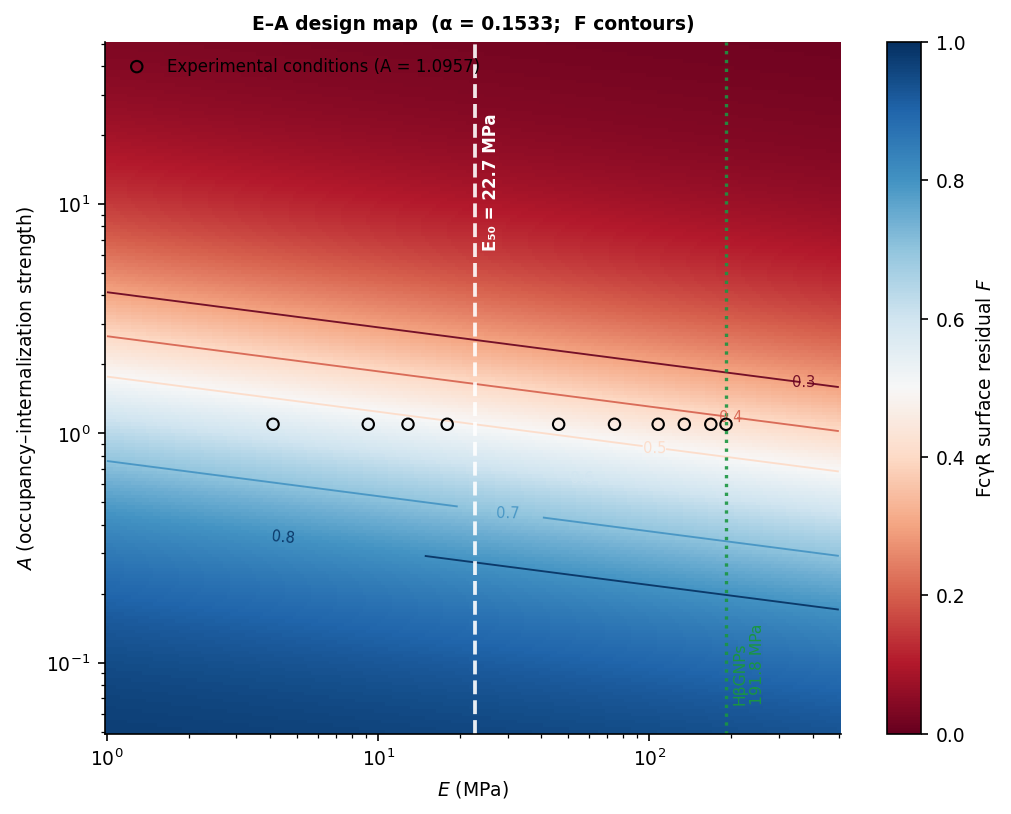

In [13]:
# ── Figure 3: E–A design map (baseline α) ────────────────────────────────────
E_HbGNPs = 191.84   # MPa — HβGNPs stiffness

E_vals = np.logspace(np.log10(1.0),  np.log10(500.), 200)
A_vals = np.logspace(np.log10(0.05), np.log10(50.),  200)
EE, AA = np.meshgrid(E_vals, A_vals)
FF     = F_model(EE, alpha_hat, AA)

fig, ax = plt.subplots(figsize=(7, 5.5))
pc = ax.pcolormesh(EE, AA, FF, shading='auto',
                   cmap='RdBu', vmin=0, vmax=1)
cs = ax.contour(EE, AA, FF,
                levels=[0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
                cmap='RdBu', linewidths=0.9, alpha=0.9)
ax.clabel(cs, fmt='%.1f', fontsize=7, inline=True)

# E₅₀ line at fitted A
ax.axvline(E50_hat, color='white', lw=1.8, ls='--', alpha=0.9)
ax.text(E50_hat * 1.06, A_vals[-1] / 2.0,
        f'E₅₀ = {E50_hat:.1f} MPa',
        color='white', fontsize=8, rotation=90,
        va='top', fontweight='bold')

# HβGNPs reference
ax.axvline(E_HbGNPs, color='#1a9641', lw=1.6, ls=':',  alpha=0.9)
ax.text(E_HbGNPs * 1.06, A_vals[8],
        f'HβGNPs\n{E_HbGNPs:.1f} MPa',
        color='#1a9641', fontsize=7.5, rotation=90, va='bottom')

ax.scatter(E_data, np.full_like(E_data, A_hat),
           facecolors='none', edgecolors='k', s=30, zorder=10,
           label=f'Experimental conditions (A = {A_hat:.4f})')

ax.set_xscale('log');  ax.set_yscale('log')
ax.set_xlabel('$E$ (MPa)', fontsize=9)
ax.set_ylabel('$A$ (occupancy–internalization strength)', fontsize=9)
ax.set_title(
    f'E–A design map  '
    f'(α = {alpha_hat:.4f};  F contours)',
    fontsize=9)
ax.legend(fontsize=8)
plt.colorbar(pc, ax=ax, label='FcγR surface residual $F$')
plt.tight_layout()
plt.show()

---
## §8 — Sensitivity Analysis

E₅₀ robustness under ±20% perturbation of α and A, individually and jointly. The HβGNPs stiffness (191.84 MPa) safety margin is computed relative to the worst-case E₅₀ across all perturbation combinations.

E₅₀ (MPa) under joint ±20% perturbation:

     α \ A      -20%      -10%        0%      +10%      +20%
      -20%  120.6352    46.1656    19.5506     8.9866     4.4200  
      -10%  107.0638    45.5866    21.2394    10.6435     5.6644  
        0%  97.3145    45.1287    22.6948 *  12.1864     6.9078  
      +10%  90.0018    44.7575    23.9595    13.6137     8.1256  
      +20%  84.3295    44.4504    25.0671    14.9301     9.3028  

HβGNPs = 191.84 MPa
Worst-case E₅₀ (α−20%, A−20%) = 120.6352 MPa
Safety margin (HβGNPs / E₅₀_worst) = 1.5902×
Conclusion: HβGNPs exceeds worst-case E₅₀ by ≥1.59× under all ±20% perturbation scenarios.


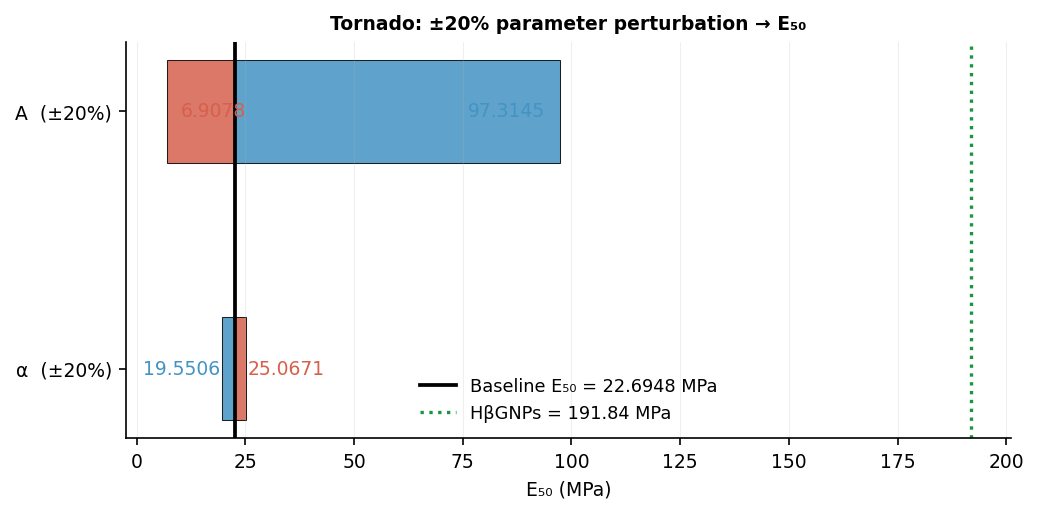

In [14]:
E_HbGNPs = 191.84
PERTURBS = [-0.20, -0.10, 0.00, +0.10, +0.20]
PLABELS  = ['-20%', '-10%', '0%', '+10%', '+20%']

# Joint perturbation matrix
E50_matrix = np.array([
    [E50_calc(alpha_hat * (1 + pa), A_hat * (1 + pA))
     for pA in PERTURBS]
    for pa in PERTURBS
])
E50_change = (E50_matrix - E50_hat) / E50_hat * 100

print('E₅₀ (MPa) under joint ±20% perturbation:\n')
print(f'  {"α \\ A":>8}', end='')
for lbl in PLABELS:
    print(f'  {lbl:>8}', end='')
print()
for i, lbl_a in enumerate(PLABELS):
    print(f'  {lbl_a:>8}', end='')
    for j in range(5):
        marker = ' *' if i == 2 and j == 2 else '  '
        print(f'  {E50_matrix[i, j]:>7.4f}{marker}', end='')
    print()

E50_worst = float(E50_matrix.max())
safety    = E_HbGNPs / E50_worst
print(f'\nHβGNPs = {E_HbGNPs} MPa')
print(f'Worst-case E₅₀ (α−20%, A−20%) = {E50_worst:.4f} MPa')
print(f'Safety margin (HβGNPs / E₅₀_worst) = {safety:.4f}×')
print(f'Conclusion: HβGNPs exceeds worst-case E₅₀ by ≥{safety:.2f}× '
      f'under all ±20% perturbation scenarios.')

# Tornado chart
fig, ax = plt.subplots(figsize=(7, 3.5))
params  = [r'α  (±20%)', 'A  (±20%)']
lo_vals = [E50_calc(alpha_hat * 0.8, A_hat),
           E50_calc(alpha_hat,       A_hat * 0.8)]
hi_vals = [E50_calc(alpha_hat * 1.2, A_hat),
           E50_calc(alpha_hat,       A_hat * 1.2)]

for i, (lo, hi) in enumerate(zip(lo_vals, hi_vals)):
    ax.barh(i, lo - E50_hat, left=E50_hat,
            color='#4393c3', alpha=0.85, height=0.4,
            edgecolor='k', linewidth=0.5)
    ax.barh(i, hi - E50_hat, left=E50_hat,
            color='#d6604d', alpha=0.85, height=0.4,
            edgecolor='k', linewidth=0.5)
    offset = max(abs(hi - E50_hat), abs(lo - E50_hat)) * 0.04 + 0.3
    ax.text(hi + offset, i, f'{hi:.4f}',
            va='center', fontsize=9, color='#d6604d')
    ax.text(lo - offset, i, f'{lo:.4f}',
            va='center', ha='right', fontsize=9, color='#4393c3')

ax.axvline(E50_hat, color='k', lw=1.8,
           label=f'Baseline E₅₀ = {E50_hat:.4f} MPa')
ax.axvline(E_HbGNPs, color='#1a9641', lw=1.6, ls=':',
           label=f'HβGNPs = {E_HbGNPs} MPa')
ax.set_yticks(range(2))
ax.set_yticklabels(params, fontsize=9)
ax.set_xlabel('E₅₀ (MPa)', fontsize=9)
ax.set_title(
    f'Tornado: ±20% parameter perturbation → E₅₀',
    fontsize=9)
ax.legend(fontsize=8.5)
ax.grid(axis='x', alpha=0.2, lw=0.5)
plt.tight_layout()
plt.show()

---
## §9 — Consolidated Parameter Report

All estimates to 4 decimal places. P-values: 4 d.p. if ≥ 0.0001, scientific notation if < 0.0001.

In [15]:
SEP = '=' * 70
print(SEP)
print('RECEPTOR KINETIC MODEL — CONSOLIDATED PARAMETER REPORT')
print(f'Primary dataset: β-glucan NPs, n = {len(E_data)} conditions')
print(f'Bootstrap: B = {N_BOOT:,}, residual resampling, seed = {SEED}')
print(SEP)

print('\n── MODEL ───────────────────────────────────────────────────────────')
print(f'  F(E) = 1 / [1 + A·(E/{E0_ref:.4f})^α]')
print(f'  U(E) = U₀·F(E)')
print(f'  E₅₀  = {E0_ref:.4f}·(1/A)^(1/α)  [analytic]')
print(f'  E₀_ref = {E0_ref:.4f} MPa  (geometric mean, fixed)')

print('\n── FITTED PARAMETERS ───────────────────────────────────────────────')
print(f'  {"Parameter":<8}  {"Estimate":>10}  {"SE":>8}  '
      f'{"Bootstrap 95% CI (B = 5,000)":>34}')
print(f'  {"α":<8}  {alpha_hat:>10.4f}  {perr[0]:>8.4f}  '
      f'[{np.percentile(alpha_b, 2.5):.4f}, '
      f'{np.percentile(alpha_b, 97.5):.4f}]')
print(f'  {"A":<8}  {A_hat:>10.4f}  {perr[1]:>8.4f}  '
      f'[{np.percentile(A_b, 2.5):.4f}, '
      f'{np.percentile(A_b, 97.5):.4f}]')
print(f'  {"U₀":<8}  {U0_hat:>10.4f}  {perr[2]:>8.4f}  '
      f'[see note]')

print('\n── THRESHOLD ───────────────────────────────────────────────────────')
print(f'  E₅₀ = {E50_hat:.4f} MPa')
print(f'  Bootstrap 95% CI: '
      f'[{np.percentile(E50_valid, 2.5):.4f}, '
      f'{np.percentile(E50_valid, 97.5):.4f}] MPa')
print(f'  Note: wide CI driven by A uncertainty amplified '
      f'by 1/α ≈ {1/alpha_hat:.1f} exponent')

print('\n── MODEL PERFORMANCE ───────────────────────────────────────────────')
print(f'  {"Metric":<28}  {"F(E)":>8}  {"U(E)":>8}')
print(f'  {"In-sample R²":<28}  {R2_F:>8.4f}  {R2_U:>8.4f}')
print(f'  {"LOO-R²":<28}  {LOO_R2_F:>8.4f}  {LOO_R2_U:>8.4f}')
print(f'  {"AIC (k = 3)":<28}  {AIC_2p:>8.4f}')
print(f'  {"BIC (k = 3)":<28}  {BIC_2p:>8.4f}')

if model_comparison_ok:
    print('\n── MODEL COMPARISON (4p vs 2p) ─────────────────────────────────────')
    print(f'  ΔAIC (4p − 2p) = {AIC_4p - AIC_2p:+.4f}  '
          f'ΔBIC = {BIC_4p - BIC_2p:+.4f}')
    print(f'  β (4p) = {b4:.2e}  → not identifiable; 2p model adopted')

print('\n── STATISTICAL VALIDATION ──────────────────────────────────────────')
print(f'  F(E): ANOVA P = {fmt_p(p_F_anova)}  |  '
      f'Kruskal–Wallis P = {fmt_p(p_F_kw)}')
print(f'  U(E): ANOVA P = {fmt_p(p_U_anova)}  |  '
      f'Kruskal–Wallis P = {fmt_p(p_U_kw)}')
print(f'  Residuals: DW(F) = {DW_F:.4f},  DW(U) = {DW_U:.4f}  '
      f'[both > 1.5, no serial correlation]')
print(f'  Shapiro–Wilk: P(F) = {fmt_p(p_sw_F)},  '
      f'P(U) = {fmt_p(p_sw_U)}  '
      f'[consistent with normality]')

print('\n── CROSS-MATERIAL VALIDATION (n = 15) ──────────────────────────────')
print(f'  NIPAM (independent):    α = {p_N[0]:.4f},  A = {p_N[1]:.4f}')
print(f'  β-glucan (independent): α = {p_B[0]:.4f},  A = {p_B[1]:.4f}')
print(f'  Joint (shared α):       α = {alpha_j:.4f},  '
      f'A_NIPAM = {A_N_j:.4f},  A_β-Glu = {A_B_j:.4f}')
print(f'  Joint R² = {R2_joint_sys:.4f}')
print(f'  Per-platform α difference: '
      f'{abs(p_N[0] - p_B[0]) / p_B[0] * 100:.0f}% '
      f'— model form universal; parameters material-specific')

print('\n── SENSITIVITY ANALYSIS ────────────────────────────────────────────')
print(f'  Baseline E₅₀ = {E50_hat:.4f} MPa')
print(f'  α −20% → E₅₀ = {E50_calc(alpha_hat*0.8, A_hat):.4f} MPa')
print(f'  α +20% → E₅₀ = {E50_calc(alpha_hat*1.2, A_hat):.4f} MPa')
print(f'  A −20% → E₅₀ = {E50_calc(alpha_hat, A_hat*0.8):.4f} MPa')
print(f'  A +20% → E₅₀ = {E50_calc(alpha_hat, A_hat*1.2):.4f} MPa')
print(f'  Worst-case E₅₀ (±20% joint) = {E50_worst:.4f} MPa')
print(f'  HβGNPs safety margin = {safety:.4f}×  '
      f'(robust under all ±20% perturbations)')

print('\n── NOTE ON U₀ ──────────────────────────────────────────────────────')
print(f'  U₀ = {U0_hat:.4f} > 1.0 is a phenomenological scaling factor.')
print(f'  It compensates for power-law under-prediction of F at low E')
print(f'  (CL1, E = {E_data[0]:.4f} MPa) and does not imply uptake')
print(f'  exceeding the Blank baseline. Valid range: E ≥ {E_data[0]:.1f} MPa.')
print(SEP)

RECEPTOR KINETIC MODEL — CONSOLIDATED PARAMETER REPORT
Primary dataset: β-glucan NPs, n = 10 conditions
Bootstrap: B = 5,000, residual resampling, seed = 2025

── MODEL ───────────────────────────────────────────────────────────
  F(E) = 1 / [1 + A·(E/41.2089)^α]
  U(E) = U₀·F(E)
  E₅₀  = 41.2089·(1/A)^(1/α)  [analytic]
  E₀_ref = 41.2089 MPa  (geometric mean, fixed)

── FITTED PARAMETERS ───────────────────────────────────────────────
  Parameter    Estimate        SE        Bootstrap 95% CI (B = 5,000)
  α             0.1533    0.0031  [0.0990, 0.2154]
  A             1.0957    0.0098  [0.9498, 1.2033]
  U₀            1.2718    0.0064  [see note]

── THRESHOLD ───────────────────────────────────────────────────────
  E₅₀ = 22.6948 MPa
  Bootstrap 95% CI: [10.9961, 57.5274] MPa
  Note: wide CI driven by A uncertainty amplified by 1/α ≈ 6.5 exponent

── MODEL PERFORMANCE ───────────────────────────────────────────────
  Metric                            F(E)      U(E)
  In-sample R²   